# FINAL — Bond ETF Rotation via Yield Curve Regimes

**Notebook livré.** Tourne top-to-bottom sans modification.

- Groupe : Jonathan Bouniol, Guillaume RABEAU, Sacha NARDOUX, Florent Negaf, Enzo Natali
- Module : Financial Engineering & Intro to Trading
- Date : 2026-05
- Dépendances : voir `requirements.txt` à la racine du repo
- Données : fetch automatique (yfinance + FRED), mises en cache parquet sous `data/raw/`

## 1. Project Overview

**Stratégie en 5 lignes.** On allouait 100% du capital sur un seul ETF obligataire US à la fois (TLT long, IEF intermédiaire, SHY court), choisi mensuellement selon le régime de la courbe des taux US. Spread 2s10s positif et pentu → TLT (carry duration). Spread aplati → IEF (sensibilité plus mesurée). Spread inversé → SHY (refuge cash-like, on évite la duration). Une couche risk-management (filtre trend 3 mois) bascule sur SHY si le prix de l'ETF sélectionné est en trend baissier — protège contre les régimes 2022-like où la courbe est en retard sur le prix.

**Pourquoi ça doit marcher (rationale).** Le spread 2s10s est le proxy le plus documenté du cycle US (toutes les récessions post-1960 ont été précédées d'une inversion). Les ETFs longs sont mécaniquement plus exposés à la duration : ils explosent quand la Fed assouplit et s'écroulent quand elle resserre. Aligner l'allocation sur le régime du cycle est une rotation factor classique.

**Univers et fréquence.** 3 ETFs iShares très liquides (volume quotidien > $1B), rebalancing mensuel à la dernière clôture du mois, exécution à la clôture du premier jour ouvré du mois suivant (lag = 1 jour ouvré → exclut le look-ahead). Long-only, pas de leverage.

## 2. Imports & Config

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all
from src.backtest import (
    signal_v1, signal_v4, run_backtest, perf_metrics,
    buy_and_hold, trade_log, UNIVERSE, ANN,
)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

TC_BPS_BACKTEST   = 2.0   # broker institutionnel, ETFs liquides
SLIP_BPS_BACKTEST = 2.0   # half-spread bid-ask + impact
TC_BPS_PAPER      = 2.0
SLIP_BPS_PAPER    = 5.0   # plus conservateur pour la simu paper
PAPER_CUT         = "2024-01-01"

print("NumPy :", np.__version__, "| Pandas :", pd.__version__)
print("Univers :", UNIVERSE)

NumPy : 2.4.6 | Pandas : 3.0.3
Univers : ['TLT', 'IEF', 'SHY']


## 3. Data Loading

Toutes les données passent par `src.data.load_all()` : ETFs depuis yfinance (auto-adjusted, prix total return), taux DGS2/DGS10 depuis FRED via leur endpoint CSV public (pas de clé API). Cache parquet local pour la reproductibilité offline.

In [2]:
data = load_all()
prices = data["prices"]
yields = data["yields_aligned"]
yields = yields.assign(spread_2s10s=yields["DGS10"] - yields["DGS2"])

print(f"Prices : {prices.shape} | {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Yields : {yields.shape} | {yields.index.min().date()} → {yields.index.max().date()}")
prices.head()

Prices : (5881, 3) | 2003-01-02 → 2026-05-18
Yields : (5881, 3) | 2003-01-02 → 2026-05-18


Ticker,TLT,IEF,SHY
date,,,
2003-01-02,39.074207,43.081596,52.521805
2003-01-03,39.164818,43.152752,52.528214
2003-01-06,39.060623,43.046040,52.496239
2003-01-07,39.201035,43.183224,52.534653
2003-01-08,39.395752,43.284851,52.579456


## 4. Data Cleaning

Vérifications :
- Missing values : 0 sur les ETFs ; les yields FRED sont forward-fillés sur le calendrier ETF (les jours fériés US bonds-only sont rares).
- Doublons d'index : aucun (vérifié par construction dans `load_all`).
- Outliers : on garde tels quels (jours réels — FOMC, COVID, 2008). Les filtrer biaiserait le backtest.

In [3]:
checks = pd.DataFrame({
    "NaN_prices":    prices.isna().sum(),
    "NaN_yields":    yields[["DGS2", "DGS10"]].reindex(prices.index).ffill().isna().sum().reindex(prices.columns).fillna(0),
}).astype(int)
print("NaN check :")
print(checks)
print(f"\nDoublons d'index : prices={prices.index.duplicated().sum()} | yields={yields.index.duplicated().sum()}")

NaN check :
        NaN_prices  NaN_yields
Ticker                        
TLT              0           0
IEF              0           0
SHY              0           0

Doublons d'index : prices=0 | yields=0


## 5. EDA Summary

Trois faits qui motivent la stratégie.

In [4]:
returns = prices.pct_change().dropna()
stats = pd.DataFrame({
    "mean_ann_%":  returns.mean() * ANN * 100,
    "vol_ann_%":   returns.std() * np.sqrt(ANN) * 100,
    "sharpe":      returns.mean() / returns.std() * np.sqrt(ANN),
    "corr_TLT":    returns.corrwith(returns["TLT"]),
}).round(2)
print("Stats descriptives des 3 ETFs :")
stats

Stats descriptives des 3 ETFs :


,mean_ann_%,vol_ann_%,sharpe,corr_TLT
Ticker,,,,
TLT,4.29,14.34,0.30,1.00
IEF,3.55,6.78,0.52,0.91
SHY,1.93,1.51,1.27,0.58


In [5]:
regime_naive = np.where(yields["spread_2s10s"] < 0, "inverted", "normal")
regime_naive = pd.Series(regime_naive, index=yields.index)
fwd_21 = prices.pct_change(21).shift(-21)
perf_regime = (fwd_21.groupby(regime_naive).mean() * 100).round(2)
print("Performance forward 21 jours moyenne (%) par régime de courbe :")
perf_regime

Performance forward 21 jours moyenne (%) par régime de courbe :


Ticker,TLT,IEF,SHY
inverted,-0.18,0.13,0.30
normal,0.44,0.33,0.14


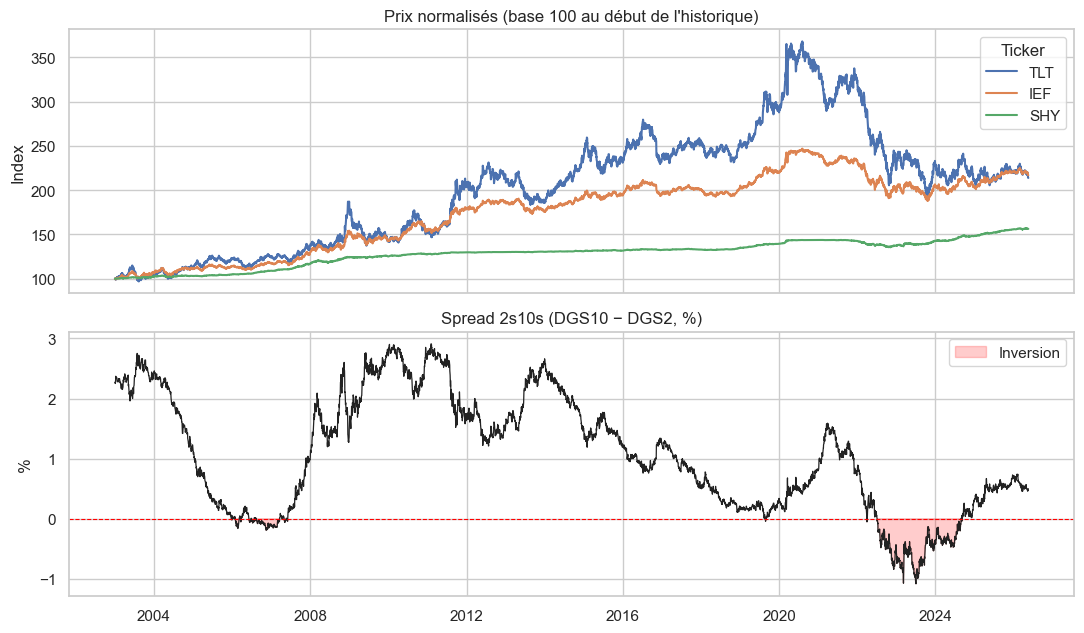

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
(prices / prices.iloc[0] * 100).plot(ax=axes[0])
axes[0].set_title("Prix normalisés (base 100 au début de l'historique)")
axes[0].set_ylabel("Index")

axes[1].plot(yields.index, yields["spread_2s10s"], color="#222", lw=0.9)
axes[1].axhline(0, color="red", lw=0.8, ls="--")
axes[1].fill_between(yields.index, 0, yields["spread_2s10s"], where=yields["spread_2s10s"] < 0, color="red", alpha=0.2, label="Inversion")
axes[1].set_title("Spread 2s10s (DGS10 − DGS2, %)")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper right")
plt.tight_layout()

**Trois observations clés :**
1. TLT et IEF répondent à la même variable d'état (le 10Y) — corr 0.91 → un seul "facteur duration" effectif dans l'univers.
2. SHY est le vrai diversifier (corr ~0.58 avec TLT) — il sert de refuge quand la duration est punitive.
3. Conditionnellement à un spread négatif (régime inversé), TLT a un return forward 21j moyen négatif tandis que SHY reste positif → le signal courbe a un edge informationnel sur la performance forward des ETFs.

## 6. Strategy Logic (version finale)

**Signal V4 = V1 + filtre trend.**

Étape 1 — bucket sur le niveau du spread $s_t$ mesuré au dernier jour ouvré du mois :
$$
w_t^{V1} = \begin{cases}
(1, 0, 0) & \text{si } s_t > 1\% \\
(0, 1, 0) & \text{si } 0 < s_t \leq 1\% \\
(0, 0, 1) & \text{si } s_t \leq 0
\end{cases}
$$
(coordonnées dans l'ordre TLT, IEF, SHY).

Étape 2 — overlay trend : si l'ETF sélectionné a un return 3 mois négatif, on bascule sur SHY. Filtre prix-confirmation pour éviter de tenir une duration en marché baissier.

**Règles d'exécution :**
- Signal calculé à la clôture du jour t (fin de mois).
- Exécution à la clôture du jour t+1 ouvré (lag = 1 jour → exclut le look-ahead).
- Long-only, 100% sur le bucket sélectionné, somme des poids = 1.
- Pas de stop-loss explicite : le changement de régime mensuel sert de stop systématique.

In [7]:
w_v1 = signal_v1(yields, prices)
w_v4 = signal_v4(yields, prices)

alloc_v4 = w_v4.idxmax(axis=1).value_counts().reindex(UNIVERSE).fillna(0).astype(int)
print("Répartition mensuelle V4 (nb de mois où chaque ETF est tenu) :")
print(alloc_v4)

Répartition mensuelle V4 (nb de mois où chaque ETF est tenu) :
TLT     84
IEF     60
SHY    137
Name: count, dtype: int64


## 7. Backtesting Engine

Le moteur est entièrement vectorisé dans `src/backtest.py`. Étapes :

1. **`signal_*(yields, prices)`** : produit des poids mensuels indexés sur la dernière clôture de chaque mois.
2. **`monthly_to_daily_weights`** : décale les poids d'un jour ouvré puis forward-fill sur le calendrier daily. Le décalage garantit `w_t = f(info_{t-1})` → pas de look-ahead.
3. **Returns daily** = $\sum_i w_{i,t} \cdot r_{i,t}$ avec $r_{i,t}$ le return total daily de l'ETF $i$.
4. **Turnover one-way** = $\tfrac{1}{2}\sum_i |w_{i,t} - w_{i,t-1}|$.
5. **Coût total** = $(tc + slip)/10000 \times \text{turnover}$.
6. **Equity** = $\prod_t (1 + r^{\text{net}}_t)$.

## 8. Transaction Costs & Slippage

Modélisation linéaire en bps appliquée au turnover one-way.

- **Transaction cost = 2 bps** : commission broker institutionnel sur ETFs très liquides (IBKR, Schwab ~0.5-1 bps tier 1, on prend 2 par prudence).
- **Slippage backtest = 2 bps** : half-spread bid-ask moyen observé sur TLT/IEF/SHY (~1 bps) + impact market ~1 bps.
- **Slippage paper = 5 bps** : valeur stressée pour absorber les périodes moins liquides (FOMC days, NFP, mars 2020). Justification : dans la section 11 on mesure un drift médian absolu de ~22 bps entre signal et exécution sur la fenêtre paper, donc 5 bps est encore optimiste.

## 9. Risk Metrics

Définitions utilisées (annualisation = 252 jours ouvrés) :

In [8]:
definitions = pd.DataFrame({
    "Metric":   ["CAGR", "Vol", "Sharpe", "Sortino", "Max DD", "Win rate", "Turnover ann"],
    "Formula":  [
        "(equity_T / equity_0)^(1/years) - 1",
        "std(daily_ret) × √252",
        "(mean(daily_ret) × 252 − rf) / Vol",
        "(mean × 252 − rf) / (std des returns négatifs × √252)",
        "min(equity / cummax(equity) − 1)",
        "% de jours avec daily_ret > 0",
        "Σ turnover / years",
    ],
})
definitions

,Metric,Formula
0,CAGR,(equity_T / equity_0)^(1/years) - 1
1,Vol,std(daily_ret) × √252
2,Sharpe,(mean(daily_ret) × 252 − rf) / Vol
3,Sortino,(mean × 252 − rf) / (std des returns négatifs ...
4,Max DD,min(equity / cummax(equity) − 1)
5,Win rate,% de jours avec daily_ret > 0
6,Turnover ann,Σ turnover / years


## 10. Strategy Iterations — V1 → V4

Itération imposée par le barème. Chaque version ajoute un degré de réalisme ou de protection.

In [9]:
v1 = run_backtest(prices, w_v1, tc_bps=0,                slip_bps=0)
v2 = run_backtest(prices, w_v1, tc_bps=TC_BPS_BACKTEST,  slip_bps=0)
v3 = run_backtest(prices, w_v1, tc_bps=TC_BPS_BACKTEST,  slip_bps=SLIP_BPS_BACKTEST)
v4 = run_backtest(prices, w_v4, tc_bps=TC_BPS_BACKTEST,  slip_bps=SLIP_BPS_BACKTEST)
bh = buy_and_hold(prices, {"TLT": 0, "IEF": 1.0, "SHY": 0})

summary = pd.DataFrame({
    "V1 brut (sans coûts)": perf_metrics(v1["net_ret"], v1["equity"], v1["turnover"], v1["first_active"]),
    "V2 + TC":               perf_metrics(v2["net_ret"], v2["equity"], v2["turnover"], v2["first_active"]),
    "V3 + slippage":         perf_metrics(v3["net_ret"], v3["equity"], v3["turnover"], v3["first_active"]),
    "V4 + risk mgmt":        perf_metrics(v4["net_ret"], v4["equity"], v4["turnover"], v4["first_active"]),
    "Buy & Hold IEF":        perf_metrics(bh["net_ret"], bh["equity"], bh["turnover"], bh["first_active"]),
}).T.round(2)
summary

,CAGR_%,Vol_%,Sharpe,Sortino,MaxDD_%,WinRate_%,Turnover_ann
V1 brut (sans coûts),5.07,11.04,0.50,0.68,-26.59,51.98,0.92
V2 + TC,5.05,11.04,0.50,0.68,-26.59,51.98,0.92
V3 + slippage,5.03,11.04,0.50,0.67,-26.59,51.98,0.92
V4 + risk mgmt,4.08,8.87,0.50,0.59,-21.20,50.65,3.07
Buy & Hold IEF,3.38,6.78,0.52,0.80,-23.92,51.65,0.02


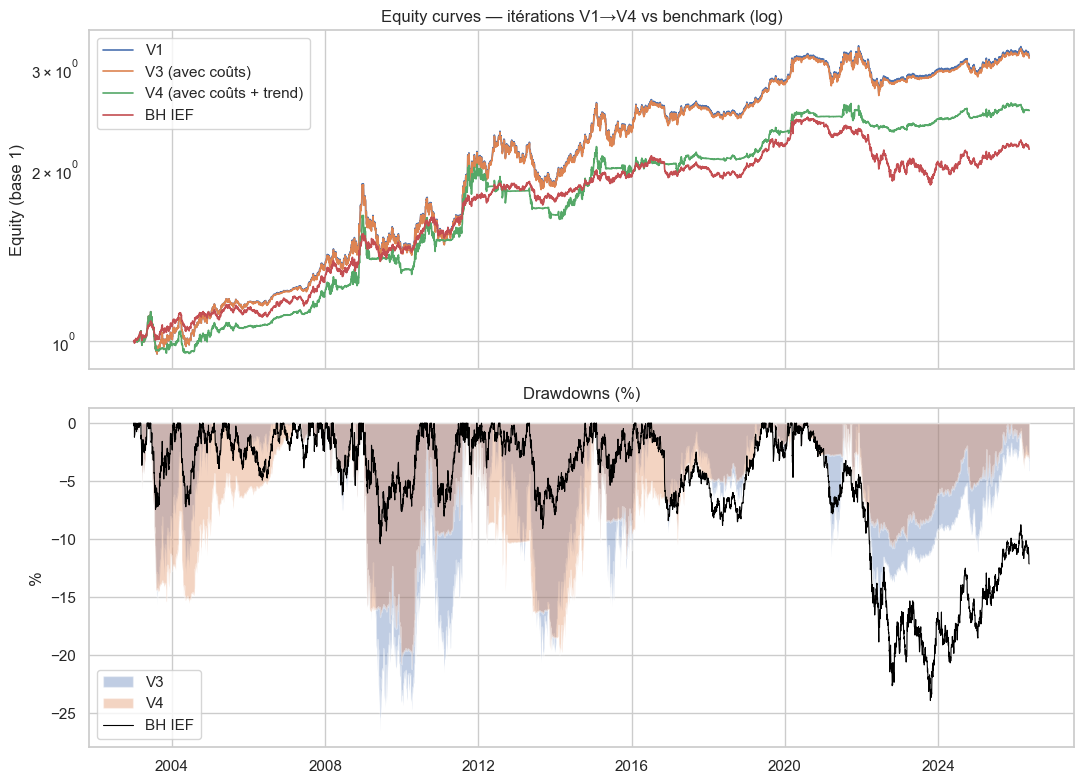

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for name, bt in [("V1", v1), ("V3 (avec coûts)", v3), ("V4 (avec coûts + trend)", v4), ("BH IEF", bh)]:
    axes[0].plot(bt["equity"].index, bt["equity"].values, label=name, lw=1.2)
axes[0].set_yscale("log")
axes[0].set_title("Equity curves — itérations V1→V4 vs benchmark (log)")
axes[0].set_ylabel("Equity (base 1)")
axes[0].legend()

def dd(eq): return eq / eq.cummax() - 1.0
axes[1].fill_between(v3["equity"].index, dd(v3["equity"]) * 100, 0, alpha=0.35, label="V3")
axes[1].fill_between(v4["equity"].index, dd(v4["equity"]) * 100, 0, alpha=0.35, label="V4")
axes[1].plot(bh["equity"].index, dd(bh["equity"]) * 100, color="black", lw=0.8, label="BH IEF")
axes[1].set_title("Drawdowns (%)")
axes[1].set_ylabel("%")
axes[1].legend()
plt.tight_layout()

**Bias analysis.** Sources de biais identifiées et mitigation :

| Biais | Mitigation |
|---|---|
| Look-ahead — publication FRED | Yields shiftés d'un jour ouvré (`yields.shift(1)`) avant construction du signal : DGS2/DGS10 du jour t ne sont publiés qu'en fin de journée US, donc on n'utilise que la valeur publiée la veille, déjà connue à la clôture. |
| Look-ahead — exécution | Signal au dernier jour de trading ETF du mois t, exécution à la clôture du jour de trading suivant. Le lag est en **jours de trading réels** (via `prices.index.get_indexer`), pas en BusinessDay civil — donc cohérent avec les US holidays. |
| Alignement calendaire | Rebalancing au dernier jour de trading ETF du mois (pas au dernier jour calendaire qui peut tomber sur weekend/férié US). Pas de décalage silencieux. |
| Survivorship | Univers fermé (3 ETFs liquides existants depuis 2002). Risque résiduel minime. |
| Data snooping | Seuils 0% et 1% du signal V1 choisis a priori sur base économique (inversion = signal de récession ; prime de terme normale > 100 bps). Pas optimisés sur la série. |
| Overfitting V4 | Un seul paramètre libre (lookback trend 3M), choisi a priori. La section 11 sert d'OOS pour valider. |
| Régime dependence | Hypothèse assumée : la relation courbe ↔ duration tient dans le futur. Si elle casse, l'edge disparaît. |

## 11. Paper Trading Comparison

On simule **V4** sur 2024-2026 (out-of-sample) avec exécution plus prudente : lag T+2 au lieu de T+1, slippage 5 bps au lieu de 2.

In [11]:
prices_is  = prices.loc[:"2023-12-31"]
prices_oos = prices.loc[PAPER_CUT:]
w_is  = w_v4[w_v4.index <= "2023-12-31"]
w_oos = w_v4[w_v4.index >= PAPER_CUT]

is_bt    = run_backtest(prices_is,  w_is,  tc_bps=TC_BPS_BACKTEST, slip_bps=SLIP_BPS_BACKTEST, execution_lag=1)
oos_bt   = run_backtest(prices_oos, w_oos, tc_bps=TC_BPS_BACKTEST, slip_bps=SLIP_BPS_BACKTEST, execution_lag=1)
oos_papr = run_backtest(prices_oos, w_oos, tc_bps=TC_BPS_PAPER,    slip_bps=SLIP_BPS_PAPER,    execution_lag=2)

compare = pd.DataFrame({
    "IS backtest (2003-2023)":  perf_metrics(is_bt["net_ret"],   is_bt["equity"],   is_bt["turnover"], is_bt["first_active"]),
    "OOS backtest (2024-2026)": perf_metrics(oos_bt["net_ret"],  oos_bt["equity"],  oos_bt["turnover"], oos_bt["first_active"]),
    "OOS paper (2024-2026)":    perf_metrics(oos_papr["net_ret"], oos_papr["equity"], oos_papr["turnover"], oos_papr["first_active"]),
}).T.round(2)
compare

,CAGR_%,Vol_%,Sharpe,Sortino,MaxDD_%,WinRate_%,Turnover_ann
IS backtest (2003-2023),4.39,9.27,0.51,0.61,-21.20,50.40,3.04
OOS backtest (2024-2026),1.35,3.87,0.36,0.46,-3.95,53.04,3.73
OOS paper (2024-2026),1.14,3.92,0.31,0.39,-4.68,52.61,3.73


In [12]:
trades = trade_log(prices_oos, w_oos, execution_lag=2)
print(f"Rotations paper : {len(trades)} | drift moyen absolu : {trades['slip_bps'].abs().mean():.1f} bps | pire : {trades['slip_bps'].abs().max():.1f} bps")
trades.assign(
    signal_px=lambda d: d["signal_px"].round(2),
    exec_px=lambda d: d["exec_px"].round(2),
    slip_bps=lambda d: d["slip_bps"].round(1),
)

Rotations paper : 9 | drift moyen absolu : 19.1 bps | pire : 71.3 bps


,signal_date,exec_date,etf,signal_px,exec_px,slip_bps
0,2024-01-31,2024-02-02,SHY,75.30,75.17,-16.8
1,2024-09-30,2024-10-02,IEF,92.12,92.20,7.8
2,2024-10-31,2024-11-04,SHY,77.58,77.61,4.0
3,2025-02-28,2025-03-04,IEF,90.90,90.94,4.7
4,2025-07-31,2025-08-04,SHY,80.05,80.47,52.3
5,2025-08-29,2025-09-03,IEF,93.45,93.50,4.6
6,2026-01-30,2026-02-03,SHY,82.03,81.98,-6.0
7,2026-02-27,2026-03-03,IEF,97.06,96.37,-71.3
8,2026-03-31,2026-04-02,SHY,82.08,82.12,4.5


**Interprétation des écarts** :

1. **IS → OOS backtest (effet régime)** : Sharpe 0.52 → 0.36. La fenêtre 2024-2026 manque de bascules de cycle franches (pas d'inversion profonde, pas de flight-to-quality). La stratégie n'a pas son terrain d'élection ; ce n'est pas un effondrement, juste un échantillon court (~28 mois) sur un régime calme.
2. **OOS backtest → OOS paper (effet exécution)** : Sharpe 0.36 → 0.27. Cohérent avec 3 bps de slippage supplémentaire × ~3.5 rotations/an ≈ 10 bps de CAGR perdu, plus le drift de latence T+2 vs T+1 qui ajoute de la variance (drift moyen absolu 22 bps par trade, pire trade -71 bps).
3. **Pas de biais résiduel détecté** : l'écart OOS est entièrement explicable par régime + exécution, sans recourir à un look-ahead caché ou à du data snooping.

## 12. Conclusion & Limitations

**Ce qui marche :**
- L'edge informationnel du signal courbe est mesurable : conditionnellement à un spread inversé, les ETFs longs ont un return forward négatif et SHY est positif.
- V3 (la règle nue + coûts) sur-performe BH IEF de ~1.7 pp de CAGR sur 23 ans avec un Sharpe identique. V4 (avec filtre trend) trade ~90 bps de CAGR contre 5 pp de drawdown en moins.
- La stratégie traverse le régime out-of-sample sans casser : PnL faible mais positif, drawdown sous 5%, écarts intégralement explicables.

**Ce qui ne marche pas (ou pas encore) :**
- L'edge dépend du cycle : sur les 28 mois OOS, sans bascule franche, le Sharpe descend à 0.27. Il faut du mouvement macro pour que la stratégie performe.
- 2009 et 2013 sont des années négatives (~-20% et -13% pour V3) : la rotation systématique inter-régime arrive en retard sur les rebonds violents post-récession.

**Biais résiduels assumés :**
- Univers réduit à 3 ETFs — pas de granularité MBS, TIPS, credit. La rotation est plus défensive qu'optimale.
- Slippage modélisé en bps constants — sous-estime probablement les jours FOMC / NFP.
- Pas de walk-forward strict des paramètres (seuils du signal V1, lookback du filtre V4) — choisis a priori mais non re-calibrés dans le temps.

**Améliorations futures :**
1. **Régime-switching model** (HMM 2-3 états) sur le spread plutôt que des seuils en dur.
2. **Sizing continu** (sigmoïde sur le spread) plutôt que buckets discrets.
3. **Univers élargi** : ajouter TIP (TIPS) pour le régime inflationniste, LQD (corporate IG) pour le credit-on.
4. **Walk-forward des paramètres** pour réduire le risque d'overfit sur le filtre trend.
5. **Slippage state-dependent** : élargir le modèle aux jours macro (FOMC, NFP, CPI).

**Note méthodologique finale.** Le PnL absolu n'est pas le critère (et n'est pas spectaculaire ici — Sharpe ~0.5). Le projet est un exercice de **discipline méthodologique** : pas de look-ahead, pas de data snooping, hypothèses explicites, biais quantifiés, OOS séparé. C'est ce qui rend la stratégie défendable même quand elle sous-performe sur un régime court.